In [7]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATIONS AND PATIENT MAPPING
# ==========================================
MODELS_DIR = "../data/models_opt/forecasting_patients/"
DATA_DIR = "../data/csv/"
os.makedirs(MODELS_DIR, exist_ok=True)

INPUT_WINDOW = 18  # 90 minutes
OUTPUT_WINDOW = 12  # 60 minutes
BATCH_SIZE = 64
EPOCHS = 50
LR = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Physiological bounds for strict scaling (0-400 mg/dL)
PHYSIO_SCALER = MinMaxScaler(feature_range=(0, 1))
PHYSIO_SCALER.fit(np.array([[0], [400]]))

# Define Training and Testing files explicitly per patient
# NOTE: Ensure the chronological order is respected (Train files are older than Test files)
PATIENT_DATA_MAP = {

    "Patient_1": {
        "train": ["patient_1/glucoseLevel.csv"],
        "test": [
            "patient_1/glucoseLevel2.csv",
            "patient_1/glucoseLevel3.csv",
            "patient_1/Clarity_Esporta_patient_1_2025-12-19_133917.csv",
            "patient_1/Clarity_Esporta_patient_1__2025-12-19_133933.csv",
            "patient_1/Clarity_Esporta__patient_1_2025-12-19_133927.csv",
            "patient_1/Clarity_Esporta_patient_1_2025-12-19_134020.csv",
            "patient_1/glucose_level_giallo.csv"
        ],
        "split_mode": "multi_file"
    },
    "Patient_12": {
        "train": ["patient_12/Clarity_Esporta_patient_12_2026-03-24_205813.csv"],
        "test": [
            "patient_12/Clarity_Esporta_patient_122026-03-24_210102.csv",
            "patient_12/Clarity_Esporta_patient_12_2026-03-24_210508.csv"
        ],
        "split_mode": "multi_file"
    },

    "Patient_14": {
        "train": ["patient_14/dexcom_esterno.csv"],
        "test": ["patient_14/dexcom_esterno.csv"],
        "split_mode": "single_file_80_20"
    },
    "Patient_15": {
        "train": ["patient_15/export_1.csv", "patient_15/export_2.csv"],
        "test": [
            "patient_15/export_3.csv", "patient_15/export_4.csv",
            "patient_15/export_5.csv", "patient_15/export_6.csv",
            "patient_15/export_7.csv"
        ],
        "split_mode": "multi_file"
    }
}


# ==========================================
# 2. MODEL ARCHITECTURE & METRICS
# ==========================================
class PatientSpecificLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_dim=64, output_steps=12):
        super(PatientSpecificLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_steps)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def clarke_error_grid_analysis(ref_values, pred_values):
    zones = {'A': 0, 'B': 0, 'C': 0, 'D': 0, 'E': 0}
    total = len(ref_values)
    if total == 0: return zones

    for ref, pred in zip(ref_values, pred_values):
        if ref == 0: continue
        abs_diff_rel = abs(ref - pred) / ref
        if abs_diff_rel <= 0.20:
            zones['A'] += 1
        elif (pred >= 70 and ref >= 70) or (pred <= 70 and ref <= 70):
            zones['B'] += 1
        elif (ref < 70 and pred > 180) or (ref > 180 and pred < 70):
            zones['E'] += 1
        else:
            zones['D'] += 1

    return {k: (v / total) * 100 for k, v in zones.items()}


# ==========================================
# 3. DATA PROCESSING
# ==========================================
def extract_glucose_series(file_path):
    full_path = os.path.join(DATA_DIR, file_path)
    if not os.path.exists(full_path):
        print(f"[WARNING] File not found: {full_path}")
        return np.array([])

    try:
        df = pd.read_csv(full_path, sep=';')
        if len(df.columns) < 2: df = pd.read_csv(full_path, sep=',')
    except:
        return np.array([])

    target_col = next((c for c in df.columns if "lucose" in c or "glucosio" in c), None)
    if not target_col: return np.array([])

    df[target_col] = df[target_col].replace("Basso", 40)
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    df[target_col] = df[target_col].interpolate(method='linear', limit=3)

    return df.dropna(subset=[target_col])[target_col].values.reshape(-1, 1)


def build_sequences(data_array):
    if len(data_array) < (INPUT_WINDOW + OUTPUT_WINDOW): return [], []
    data_scaled = PHYSIO_SCALER.transform(data_array)
    xs, ys = [], []
    for i in range(len(data_scaled) - INPUT_WINDOW - OUTPUT_WINDOW + 1):
        xs.append(data_scaled[i:(i + INPUT_WINDOW)])
        ys.append(data_scaled[(i + INPUT_WINDOW):(i + INPUT_WINDOW + OUTPUT_WINDOW)])
    return np.array(xs), np.array(ys)


# ==========================================
# 4. TRAINING & EVALUATION PIPELINE
# ==========================================
def train_patient_model(patient_id, X_train, y_train):
    print(f"[{patient_id}] Starting Training ({len(X_train)} sequences)...")
    model = PatientSpecificLSTM(output_steps=OUTPUT_WINDOW).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    X_t = torch.FloatTensor(X_train).to(DEVICE)
    y_t = torch.FloatTensor(y_train).squeeze(-1).to(DEVICE)
    dataset = torch.utils.data.TensorDataset(X_t, y_t)
    loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    best_loss = float('inf')
    save_path = os.path.join(MODELS_DIR, f"model_{patient_id}.pth")

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for b_x, b_y in loader:
            optimizer.zero_grad()
            loss = criterion(model(b_x), b_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), save_path)

    print(f"[{patient_id}] Training Completed. Best Loss: {best_loss:.6f}")
    return save_path


def evaluate_patient_model(patient_id, model_path, X_test, y_test):
    print(f"[{patient_id}] Evaluating on Test Set ({len(X_test)} sequences)...")
    model = PatientSpecificLSTM(output_steps=OUTPUT_WINDOW).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    X_t = torch.FloatTensor(X_test).to(DEVICE)

    with torch.no_grad():
        preds_scaled = model(X_t).cpu().numpy()

    y_real = PHYSIO_SCALER.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape[0], OUTPUT_WINDOW)
    preds_real = PHYSIO_SCALER.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(preds_scaled.shape[0],
                                                                                      OUTPUT_WINDOW)

    last_known = PHYSIO_SCALER.inverse_transform(X_test[:, -1, :])
    naive_preds = np.repeat(last_known, OUTPUT_WINDOW, axis=1)

    mae_ai = mean_absolute_error(y_real, preds_real)
    mae_naive = mean_absolute_error(y_real, naive_preds)
    rmse_ai = np.sqrt(mean_squared_error(y_real, preds_real))
    clarke = clarke_error_grid_analysis(y_real.flatten(), preds_real.flatten())

    return {
        "Patient": patient_id,
        "Test_Samples": len(y_real),
        "MAE_AI": mae_ai,
        "RMSE_AI": rmse_ai,
        "MAE_Naive": mae_naive,
        "Improvement_%": ((mae_naive - mae_ai) / mae_naive) * 100,
        "Clarke_A_%": clarke.get('A', 0),
        "Clarke_B_%": clarke.get('B', 0)
    }


# ==========================================
# 5. MAIN EXECUTION
# ==========================================
def main():
    print("=" * 60)
    print(" INITIALIZING PATIENT-SPECIFIC FORECASTING PIPELINE")
    print("=" * 60)

    global_metrics = []

    for patient_id, config in PATIENT_DATA_MAP.items():
        print(f"\nProcessing {patient_id}...")

        # --- 1. Load Data ---
        train_data = np.concatenate(
            [extract_glucose_series(f) for f in config["train"] if len(extract_glucose_series(f)) > 0])
        test_data = np.concatenate(
            [extract_glucose_series(f) for f in config["test"] if len(extract_glucose_series(f)) > 0]) if config[
            "test"] else np.array([])

        if len(train_data) == 0:
            print(f"[{patient_id}] Insufficient Training Data. Skipping.")
            continue

        # --- 2. Build Sequences & Split ---
        if config["split_mode"] == "single_file_80_20":
            X_all, y_all = build_sequences(train_data)
            split_idx = int(len(X_all) * 0.8)
            X_train, y_train = X_all[:split_idx], y_all[:split_idx]
            X_test, y_test = X_all[split_idx:], y_all[split_idx:]
        else:
            X_train, y_train = build_sequences(train_data)
            X_test, y_test = build_sequences(test_data)

        if len(X_train) == 0 or len(X_test) == 0:
            print(f"[{patient_id}] Insufficient Sequences after windowing. Skipping.")
            continue

        # --- 3. Train & Evaluate ---
        model_path = train_patient_model(patient_id, X_train, y_train)
        metrics = evaluate_patient_model(patient_id, model_path, X_test, y_test)
        global_metrics.append(metrics)

    # --- 6. AGGREGATED REPORT ---
    if not global_metrics:
        print("\n[ERROR] No patients were successfully processed.")
        return

    df_results = pd.DataFrame(global_metrics)

    print(f"\n{'=' * 80}")
    print(" FINAL ACADEMIC REPORT (MACRO-AVERAGE ACROSS PATIENTS)")
    print(f"{'=' * 80}")
    print(df_res_str := df_results.to_string(index=False))

    mean_mae = df_results['MAE_AI'].mean()
    mean_imp = df_results['Improvement_%'].mean()
    mean_safe = (df_results['Clarke_A_%'] + df_results['Clarke_B_%']).mean()

    print(f"\n[GLOBAL METRICS FOR PAPER]")
    print(f" -> Average MAE across patients: {mean_mae:.2f} mg/dL")
    print(f" -> Average Improvement vs Naive: {mean_imp:.2f}%")
    print(f" -> Clinical Safety (Clarke Zone A+B): {mean_safe:.2f}%")
    print(f"{'=' * 80}\n")


if __name__ == "__main__":
    main()

 INITIALIZING PATIENT-SPECIFIC FORECASTING PIPELINE

Processing Patient_1...
[Patient_1] Starting Training (25351 sequences)...
[Patient_1] Training Completed. Best Loss: 0.003554
[Patient_1] Evaluating on Test Set (83924 sequences)...

Processing Patient_12...
[Patient_12] Starting Training (4578 sequences)...
[Patient_12] Training Completed. Best Loss: 0.005852
[Patient_12] Evaluating on Test Set (11908 sequences)...

Processing Patient_14...
[Patient_14] Starting Training (7976 sequences)...
[Patient_14] Training Completed. Best Loss: 0.001090
[Patient_14] Evaluating on Test Set (1994 sequences)...

Processing Patient_15...
[Patient_15] Starting Training (51811 sequences)...
[Patient_15] Training Completed. Best Loss: 0.009099
[Patient_15] Evaluating on Test Set (43171 sequences)...

 FINAL ACADEMIC REPORT (MACRO-AVERAGE ACROSS PATIENTS)
   Patient  Test_Samples    MAE_AI   RMSE_AI  MAE_Naive  Improvement_%  Clarke_A_%  Clarke_B_%
 Patient_1         83924 17.248342 24.865304  19.408

Generazione immagini in corso... (richiederà pochi secondi)
Salvata: forecasting_scatter_cikm.png
Salvata: forecasting_residuals_cikm.png
Salvata: forecasting_mae_cikm.png
Tutte le immagini sono state generate con successo!


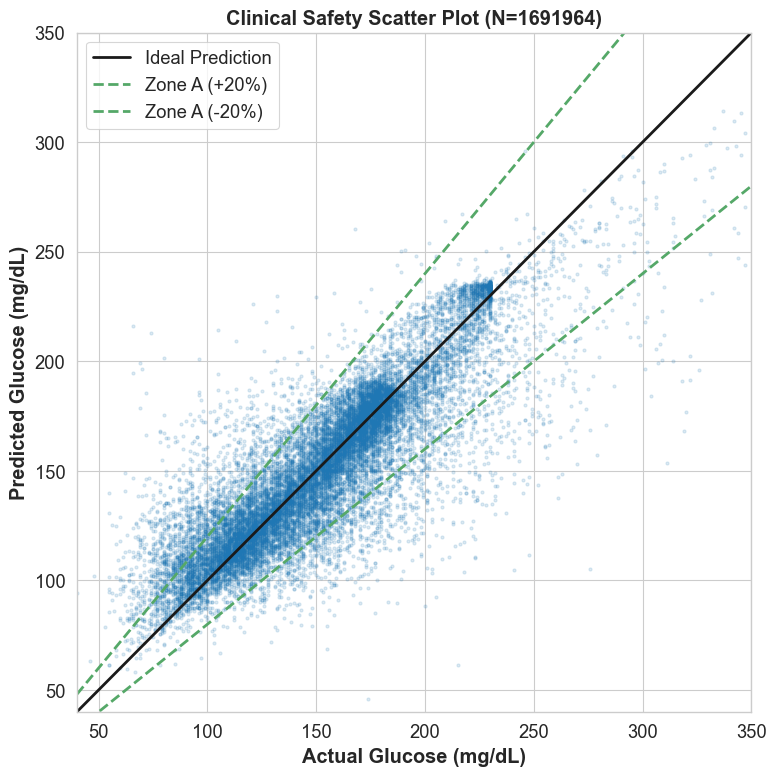

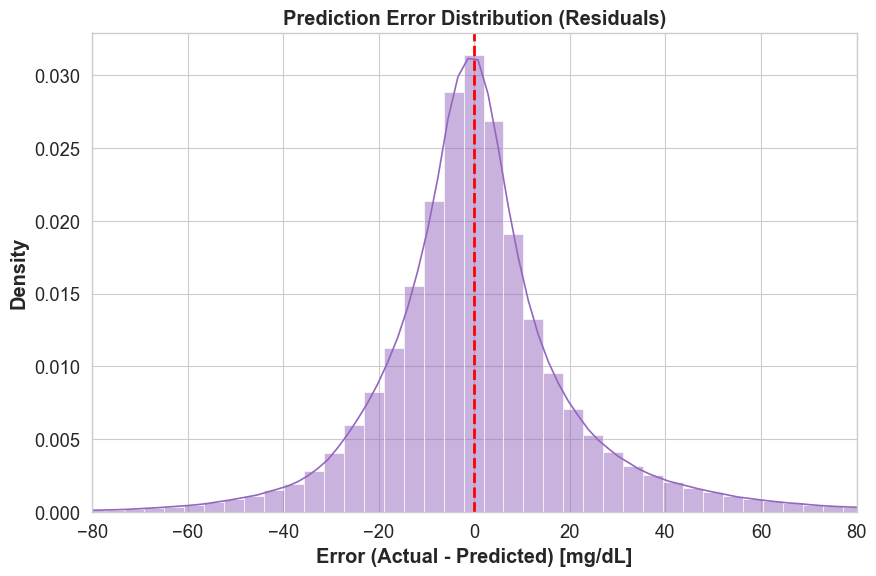

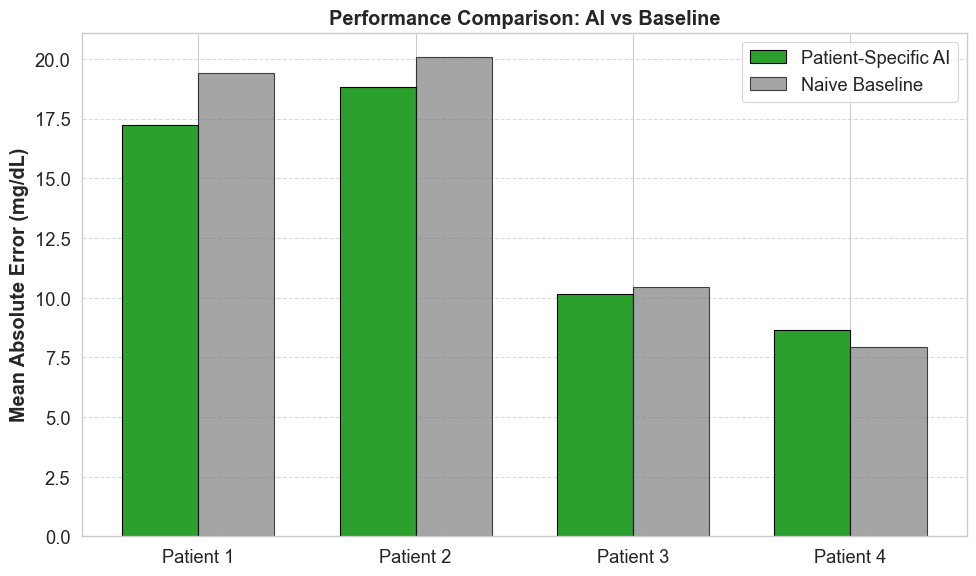

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 1. CONFIGURAZIONI BASE (Le stesse del paper)
# ==========================================
MODELS_DIR = "../data/models_opt/forecasting_patients/"
DATA_DIR = "../data/csv/"
INPUT_WINDOW = 18
OUTPUT_WINDOW = 12
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PHYSIO_SCALER = MinMaxScaler(feature_range=(0, 1))
PHYSIO_SCALER.fit(np.array([[0], [400]]))

# La mappa dei pazienti (solo i test set ci interessano ora)
PATIENT_DATA_MAP = {
    "Patient_1": {"test": ["patient_1/glucoseLevel2.csv", "patient_1/glucoseLevel3.csv", "patient_1/Clarity_Esporta_patient_1_2025-12-19_133917.csv", "patient_1/Clarity_Esporta_patient_1__2025-12-19_133933.csv", "patient_1/Clarity_Esporta__patient_1_2025-12-19_133927.csv", "patient_1/Clarity_Esporta_patient_1_2025-12-19_134020.csv", "patient_1/glucose_level_giallo.csv"]},
    "Patient_12": {"test": ["patient_12/Clarity_Esporta_patient_122026-03-24_210102.csv", "patient_12/Clarity_Esporta_patient_12_2026-03-24_210508.csv"]},
    "Patient_14": {"test": ["patient_14/dexcom_esterno.csv"], "is_split": True}, # Useremo gli ultimi 20%
    "Patient_15": {"test": ["patient_15/export_3.csv", "patient_15/export_4.csv", "patient_15/export_5.csv", "patient_15/export_6.csv", "patient_15/export_7.csv"]}
}

class PatientSpecificLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_dim=64, output_steps=12):
        super(PatientSpecificLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_steps)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def extract_glucose_series(file_path):
    full_path = os.path.join(DATA_DIR, file_path)
    if not os.path.exists(full_path): return np.array([])
    try:
        df = pd.read_csv(full_path, sep=';')
        if len(df.columns) < 2: df = pd.read_csv(full_path, sep=',')
    except: return np.array([])
    target_col = next((c for c in df.columns if "lucose" in c or "glucosio" in c), None)
    if not target_col: return np.array([])
    df[target_col] = df[target_col].replace("Basso", 40)
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce').interpolate(method='linear', limit=3)
    return df.dropna(subset=[target_col])[target_col].values.reshape(-1, 1)

def build_sequences(data_array):
    if len(data_array) < (INPUT_WINDOW + OUTPUT_WINDOW): return [], []
    data_scaled = PHYSIO_SCALER.transform(data_array)
    xs, ys = [], []
    for i in range(len(data_scaled) - INPUT_WINDOW - OUTPUT_WINDOW + 1):
        xs.append(data_scaled[i:(i + INPUT_WINDOW)])
        ys.append(data_scaled[(i + INPUT_WINDOW):(i + INPUT_WINDOW + OUTPUT_WINDOW)])
    return np.array(xs), np.array(ys)

# ==========================================
# 2. RACCOLTA DATI (INFERENZA VELOCE)
# ==========================================
print("Generazione immagini in corso... (richiederà pochi secondi)")
all_y_true, all_y_pred, patient_mae_ai, patient_mae_naive, patient_labels = [], [], [], [], []

for patient_id, config in PATIENT_DATA_MAP.items():
    model_path = os.path.join(MODELS_DIR, f"model_{patient_id}.pth")
    if not os.path.exists(model_path): continue

    model = PatientSpecificLSTM().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    test_data = np.concatenate([extract_glucose_series(f) for f in config["test"] if len(extract_glucose_series(f)) > 0]) if "test" in config and not config.get("is_split") else extract_glucose_series(config["test"][0]) if config.get("is_split") else np.array([])

    if config.get("is_split"): # Paziente 14 (prendiamo l'ultimo 20% come test)
        X_all, y_all = build_sequences(extract_glucose_series("patient_14/dexcom_esterno.csv"))
        split_idx = int(len(X_all) * 0.8)
        X_test, y_test = X_all[split_idx:], y_all[split_idx:]
    else:
        X_test, y_test = build_sequences(test_data)

    if len(X_test) == 0: continue

    with torch.no_grad():
        preds_scaled = model(torch.FloatTensor(X_test).to(DEVICE)).cpu().numpy()

    y_real = PHYSIO_SCALER.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape[0], OUTPUT_WINDOW)
    preds_real = PHYSIO_SCALER.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(preds_scaled.shape[0], OUTPUT_WINDOW)
    naive_preds = np.repeat(PHYSIO_SCALER.inverse_transform(X_test[:, -1, :]), OUTPUT_WINDOW, axis=1)

    all_y_true.extend(y_real.flatten())
    all_y_pred.extend(preds_real.flatten())
    patient_mae_ai.append(np.mean(np.abs(y_real - preds_real)))
    patient_mae_naive.append(np.mean(np.abs(y_real - naive_preds)))
    patient_labels.append(patient_id)

# ==========================================
# 3. GENERAZIONE GRAFICI PER IL PAPER CIKM
# ==========================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)

# --- FIGURA 1: CLARKE ERROR GRID (SCATTER PLOT) ---
plt.figure(figsize=(8, 8))
indices = np.random.choice(len(all_y_true), size=min(20000, len(all_y_true)), replace=False) # Campioniamo per leggibilità
plt.scatter(np.array(all_y_true)[indices], np.array(all_y_pred)[indices], alpha=0.15, color='#1f77b4', s=5)
plt.plot([40, 400], [40, 400], 'k-', linewidth=2, label='Ideal Prediction')
x_vals = np.linspace(40, 400, 100)
plt.plot(x_vals, x_vals * 1.2, 'g--', linewidth=2, label='Zone A (+20%)')
plt.plot(x_vals, x_vals * 0.8, 'g--', linewidth=2, label='Zone A (-20%)')
plt.title(f"Clinical Safety Scatter Plot (N={len(all_y_true)})", fontweight='bold')
plt.xlabel("Actual Glucose (mg/dL)", fontweight='bold')
plt.ylabel("Predicted Glucose (mg/dL)", fontweight='bold')
plt.legend(loc='upper left')
plt.xlim(40, 350)
plt.ylim(40, 350)
plt.tight_layout()
plt.savefig("forecasting_scatter_cikm.png", dpi=300)
print("Salvata: forecasting_scatter_cikm.png")

# --- FIGURA 2: RESIDUALS DISTRIBUTION ---
plt.figure(figsize=(9, 6))
errors = np.array(all_y_true) - np.array(all_y_pred)
sns.histplot(errors, bins=100, kde=True, color='#9467bd', stat='density')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title("Prediction Error Distribution (Residuals)", fontweight='bold')
plt.xlabel("Error (Actual - Predicted) [mg/dL]", fontweight='bold')
plt.ylabel("Density", fontweight='bold')
plt.xlim(-80, 80)
plt.tight_layout()
plt.savefig("forecasting_residuals_cikm.png", dpi=300)
print("Salvata: forecasting_residuals_cikm.png")

# --- FIGURA 3: MAE COMPARISON (AI vs NAIVE) ---
plt.figure(figsize=(10, 6))
x = np.arange(len(patient_labels))
width = 0.35

# NUOVA LOGICA: Rinomina le etichette in modo sequenziale (Patient 1, Patient 2...)
clean_labels = [f"Patient {i+1}" for i in range(len(patient_labels))]

plt.bar(x - width/2, patient_mae_ai, width, label='Patient-Specific AI', color='#2ca02c', edgecolor='black')
plt.bar(x + width/2, patient_mae_naive, width, label='Naive Baseline', color='#7f7f7f', alpha=0.7, edgecolor='black')
plt.title("Performance Comparison: AI vs Baseline", fontweight='bold')
plt.ylabel("Mean Absolute Error (mg/dL)", fontweight='bold')
plt.xticks(x, clean_labels) # Usa le nuove etichette pulite
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("forecasting_mae_cikm.png", dpi=300)
print("Salvata: forecasting_mae_cikm.png")

print("Tutte le immagini sono state generate con successo!")